# TSP Graph optimization

In this notebook we will create the graph with the distance data

In [331]:
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 3.8 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## Imports

In [68]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from geopy.distance import geodesic
import json
import pandas as pd
import geopandas as gpd
#import folium

## load data

In [115]:
# Path to the GeoJSON file
filename = 'municipalitiesWithADMUNADU.geojson'

# Read the GeoJSON file
with open(filename, 'r') as file:
    municipalities_fc = json.load(file)

# Print the number of features
num_features = len(municipalities_fc['features'])
print("Number of features:", num_features)

print(municipalities_fc['features'][0])

Number of features: 581
{'type': 'Feature', 'properties': {'name': 'Charleroi', 'place': 'city', 'ADMUNADU': 'CHARLEROI'}, 'geometry': {'type': 'Point', 'coordinates': [4.444528, 50.4116233]}}


In [70]:
csv_file_path = 'routes_with_directions.csv' 
distances_df = pd.read_csv(csv_file_path)

In [71]:
print(distances_df.loc[0])

start                                                  AARTSELAAR
end                                                     ANTWERPEN
coords_start                               [4.3870241, 51.133297]
coords_end                                [4.3997081, 51.2211097]
Directions      [{'bounds': {'northeast': {'lat': 51.221048300...
Distances                                                   10524
Name: 0, dtype: object


## Create a graph


In [72]:
G = nx.Graph()

In [229]:
def addNodes(fc, prop):
    nodes = []
    for feature in fc['features']:
        name = feature['properties'][prop]
        coords = tuple(feature['geometry']['coordinates'][::-1]) # Reverse to (lat, lon)
        nodes.append((name, coords))
        G.add_node(name, coordinates=coords)
    return nodes
    
nodes = addNodes(municipalities_fc, 'ADMUNADU')

In [ ]:
def get_distance_dict(df):
    distance_dict = {}
    for idx, row in df.iterrows():
        pair = (row['start'], row['end'])
        reverse_pair = (row['end'], row['start'])
        distance_dict[pair] = row['Distances']
        distance_dict[reverse_pair] = row['Distances']
    return distance_dict

# Create the distance dictionary
distance_dict = get_distance_dict(distances_df)

Takes about 15 seconds to build the graph

In [232]:
def calculate_distance(coord1, coord2):
    return geodesic(coord1, coord2).kilometers

def getDistance(name1, name2, coo1,coo2):
    return distance_dict.get((name1, name2), calculate_distance(coo1, coo2) * 1000) / 1000

def addEdges(nodes):
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            node1_name, node1_coords = nodes[i]
            node2_name, node2_coords = nodes[j]
            distance = getDistance(node1_name, node2_name, node1_coords, node2_coords)
            G.add_edge(node1_name, node2_name, weight=(distance))

In [ ]:
addEdges(nodes)

## optimize graph

In [75]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the graph connected?", "Yes" if nx.is_connected(G) else "No")

Number of nodes: 581
Number of edges: 168490
Is the graph connected? Yes


In [93]:
q = "HOVE"

connections_with_distances = []

if q in G:
    for neighbor in G[q]:
        distance = G[q][neighbor]['weight']
        connections_with_distances.append((neighbor, distance))
    connections_with_distances.sort(key=lambda x: x[1])  # Optional: sort by distance

    # Print or process the connections and distances
    print(f"Connections from {q} with distances:")
    for connection, distance in connections_with_distances:
        print(f"{q} -> {connection} = {distance} km")
else:
    print("Hove is not in the graph.")

Connections from HOVE with distances:
HOVE -> EDEGEM = 2.701 km
HOVE -> BOECHOUT = 2.791 km
HOVE -> KONTICH = 3.067 km
HOVE -> LINT = 3.101 km
HOVE -> MORTSEL = 3.252 km
HOVE -> BORSBEEK = 4.992082458875513 km
HOVE -> DUFFEL = 6.220648753747066 km
HOVE -> AARTSELAAR = 6.5495160018159515 km
HOVE -> LIER = 6.745759069032586 km
HOVE -> WOMMELGEM = 6.876672892279846 km
HOVE -> RANST = 7.5501074719350685 km
HOVE -> RUMST = 8.569448473936623 km
HOVE -> WIJNEGEM = 9.282389854615817 km
HOVE -> SINT-KATELIJNE-WAVER = 9.556692248047106 km
HOVE -> HEMIKSEM = 9.56548226488573 km
HOVE -> ANTWERPEN = 9.723710640945361 km
HOVE -> SCHELLE = 10.23847286693012 km
HOVE -> BOOM = 10.317395538088144 km
HOVE -> NIEL = 11.159803815483894 km
HOVE -> SCHOTEN = 11.552080345036055 km
HOVE -> KRUIBEKE = 12.037825334101768 km
HOVE -> SCHILDE = 12.401020807518728 km
HOVE -> WILLEBROEK = 12.828555191337905 km
HOVE -> ZWIJNDRECHT = 12.896245951303392 km
HOVE -> BERLAAR = 13.062637330833892 km
HOVE -> MECHELEN = 13.40

## Solve TSP

In [77]:
tsp_route = nx.approximation.christofides(G, weight='weight')

### Start with specific node

In [166]:
def startWithSpecificNode(giraf, start_node, tsp_route):
    # Check if the starting node exists in the graph
    if start_node in giraf:
        
        # Rotate the tour to start at 'Hove'
        start_index = tsp_route.index(start_node)
        rotated_tsp_route = tsp_route[start_index:] + tsp_route[:start_index]
        tsp_route = rotated_tsp_route
        
        print("TSP Route using Christofides algorithm starting from", start_node, ":", tsp_route)
    else:
        print(start_node, "not found in the data")
        
startWithSpecificNode(G, 'HOVE', tsp_route)

TSP Route using Christofides algorithm starting from HOVE : ['HOVE', 'BOECHOUT', 'BORSBEEK', 'WOMMELGEM', 'RANST', 'WIJNEGEM', 'SCHILDE', 'HAL', 'ZANDHOVEN', 'ZOERSEL', 'MALLE', 'BRECHT', 'WUUSTWEZEL', 'ESSEN', 'KALMTHOUT', 'KAPELLEN', 'STABROEK', 'BRASSCHAAT', 'SCHOTEN', 'ANTWERPEN', 'ZWIJNDRECHT', 'BEVEREN', 'KRUIBEKE', 'HEMIKSEM', 'SCHELLE', 'NIEL', 'BOOM', 'RUMST', 'WILLEBROEK', 'LONDERZEEL', 'KAPELLE-OP-DEN-BOS', 'PUURS-SINT-AMANDS', 'BORNEM', 'TEMSE', 'HAMME', 'WAASMUNSTER', 'ZELE', 'LOKEREN', 'BERLARE', 'WICHELEN', 'DENDERMONDE', 'LEBBEKE', 'BUGGENHOUT', 'OPWIJK', 'MERCHTEM', 'ASSE', 'TERNAT', 'DENDERLEEUW', 'LIEDEKERKE', 'HAALTERT', 'ERPE-MERE', 'HERZELE', 'OOSTERZELE', 'SINT-LIEVENS-HOUTEM', 'ZOTTEGEM', 'LIERDE', 'BRAKEL', 'HOREBEKE', 'ZWALM', 'GAVERE', 'NAZARETH', 'KRUISEM', 'DEINZE', 'DE PINTE', 'SINT-MARTENS-LATEM', 'MERELBEKE', 'MELLE', 'LAARNE', 'DESTELBERGEN', 'GENT', 'EVERGEM', 'LIEVEGEM', 'EEKLO', 'KAPRIJKE', 'SINT-LAUREINS', 'MALDEGEM', 'KNOKKE-HEIST', 'DAMME', 'BRUGG

### clean & verifiy route

In [79]:
# Example of a simple check when generating a route
def verify_route(route):
    for i in range(1, len(route)):
        if route[i] == route[i-1]:
            return False  # Indicates an issue in the route
    return True

def clean_route(route):
    cleaned_route = [route[0]]  # Start with the first node
    for node in route[1:]:
        if node != cleaned_route[-1]:
            cleaned_route.append(node)
    return cleaned_route

tsp_route = clean_route(tsp_route)

# Use this function to check your initial route
if not verify_route(tsp_route):
    print("Invalid route detected: consecutive duplicate nodes found.")

### 2-Opt optimization

Should take about 4m42s with 581 nodes
takes 6m now?

In [84]:
def two_opt(graph, initial_route):
    best_route = initial_route
    improved = True
    
    while improved:
        improved = False
        for i in range(1, len(best_route) - 2):
            for j in range(i + 1, len(best_route)):
                if j - i == 1: continue  # Skip consecutive nodes, as swapping them changes nothing
                new_route = best_route[:i] + best_route[i:j][::-1] + best_route[j:]
                
                # Calculate the cost of the routes
                old_distance = sum(graph[best_route[k]][best_route[k + 1]]['weight'] for k in range(len(best_route) - 1))
                new_distance = sum(graph[new_route[k]][new_route[k + 1]]['weight'] for k in range(len(new_route) - 1))
                
                # Check if the new route is better
                if new_distance < old_distance:
                    best_route = new_route
                    improved = True
        
        # If no improvement was found, exit the while loop
        if not improved:
            break

    return best_route

# Now apply the 2-opt algorithm to improve this route
optimized_route = two_opt(G, tsp_route)

In [85]:
tsp_route = optimized_route

### Plot

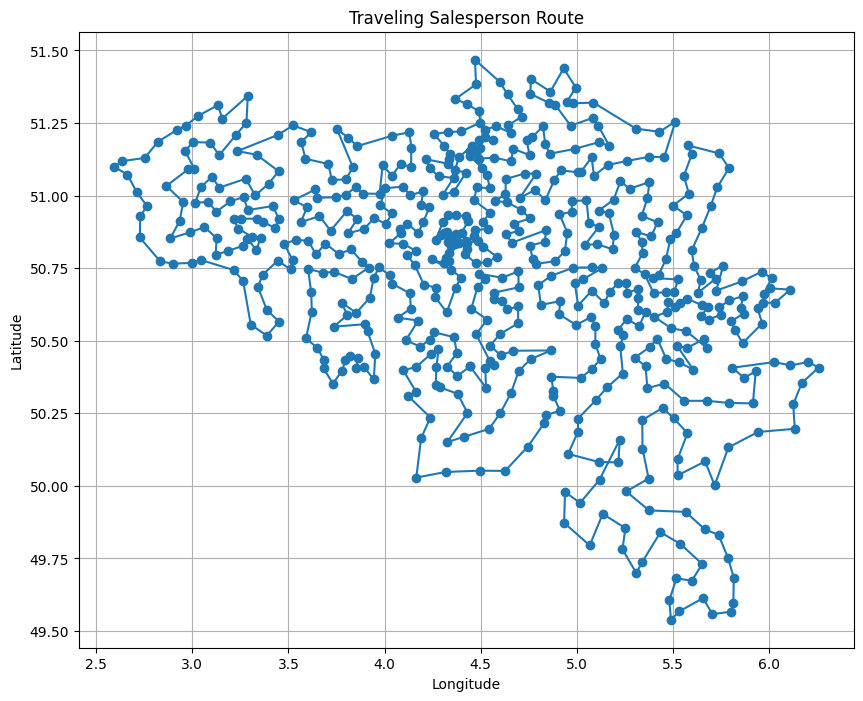

In [248]:
def plotRoute(tsp_route):
    # Plotting the route
    coords = {feature['properties']['ADMUNADU']: tuple(feature['geometry']['coordinates'][::-1]) for feature in municipalities_fc['features']}
    route_coords = [coords[place] for place in tsp_route]

    # Unpack coordinates for plotting
    lats, lons = zip(*route_coords)

    plt.figure(figsize=(10, 8))
    plt.plot(lons, lats, 'o-')  # Plot points with lines between them

    # for i, txt in enumerate(tsp_route):
    #     plt.annotate(txt, (lons[i], lats[i]))

    plt.title('Traveling Salesperson Route')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()
    
plotRoute(tsp_route)

In [250]:
def calculate_route_with_distances(tsp_route, getDistance):
    coords = {feature['properties']['ADMUNADU']: tuple(feature['geometry']['coordinates'][::-1]) for feature in municipalities_fc['features']}
    route_with_distances = []
    previous_place = None
    total_distance = 0

    for place in tsp_route:
        if previous_place is not None:
            coord1 = coords[previous_place]
            coord2 = coords[place]
            distance = getDistance(previous_place, place, coord1, coord2)
            total_distance += distance
            route_with_distances.append({
                "from": previous_place,
                "to": place,
                "distance": f"{distance:.2f} km"
            })
        previous_place = place

    # Optionally, to make the route circular
    if len(tsp_route) > 1:
        first_place = tsp_route[0]
        last_place = tsp_route[-1]
        coord1 = coords[last_place]
        coord2 = coords[first_place]
        distance = getDistance(last_place, first_place, coord1, coord2)
        total_distance += distance
        route_with_distances.append({
            "from": last_place,
            "to": first_place,
            "distance": f"{distance:.2f} km"
        })

    return route_with_distances, total_distance

def print_route(route_with_distances):
    for leg in route_with_distances:
        print(f"{leg['from']} -> {leg['to']} = {leg['distance']}")

def print_total_distance(total_distance):
    print(f"Total distance: {total_distance:.2f} km")


route_with_distances, total_distance = calculate_route_with_distances(tsp_route, getDistance)

print_route(route_with_distances)
print_total_distance(total_distance)


CHARLEROI -> GERPINNES = 11.74 km
GERPINNES -> CHATELET = 8.46 km
CHATELET -> AISEAU-PRESLES = 4.12 km
AISEAU-PRESLES -> FARCIENNES = 4.05 km
FARCIENNES -> LES BONS VILLERS = 11.26 km
LES BONS VILLERS -> VILLERS-LA-VILLE = 7.87 km
VILLERS-LA-VILLE -> GENEPIEN = 9.00 km
GENEPIEN -> LASNE = 9.86 km
LASNE -> RIXENSART = 4.22 km
RIXENSART -> TERHULPEN = 4.17 km
TERHULPEN -> WAVER = 8.69 km
WAVER -> GRAVEN = 7.44 km
GRAVEN -> CHAUMONT-GISTOUX = 6.61 km
CHAUMONT-GISTOUX -> OTTIGNIES-LOUVAIN-LA-NEU = 11.21 km
OTTIGNIES-LOUVAIN-LA-NEU -> COURT-SAINT-ETIENNE = 2.69 km
COURT-SAINT-ETIENNE -> MONT-SAINT-GUIBERT = 3.98 km
MONT-SAINT-GUIBERT -> CHASTRE = 4.49 km
CHASTRE -> WALHAIN = 4.35 km
WALHAIN -> GEMBLOUX = 7.92 km
GEMBLOUX -> SOMBREFFE = 8.58 km
SOMBREFFE -> FLEURUS = 6.22 km
FLEURUS -> SAMBREVILLE = 6.38 km
SAMBREVILLE -> JEMEPPE-SUR-SAMBRE = 5.60 km
JEMEPPE-SUR-SAMBRE -> NAMEN = 15.43 km
NAMEN -> FLOREFFE = 10.17 km
FLOREFFE -> FOSSES-LA-VILLE = 7.47 km
FOSSES-LA-VILLE -> METTET = 9.85 km
M

In [97]:
route_with_distances_df = pd.DataFrame(route_with_distances)
print(route_with_distances_df)

                     from                    to distance
0                    HOVE               MORTSEL  3.25 km
1                 MORTSEL                EDEGEM  2.49 km
2                  EDEGEM               KONTICH  2.34 km
3                 KONTICH            AARTSELAAR  5.03 km
4              AARTSELAAR               SCHELLE  4.58 km
..                    ...                   ...      ...
576                 PUTTE             BONHEIDEN  7.74 km
577             BONHEIDEN  SINT-KATELIJNE-WAVER  7.03 km
578  SINT-KATELIJNE-WAVER                DUFFEL  3.75 km
579                DUFFEL                  LINT  4.09 km
580                  LINT                  HOVE  3.10 km

[581 rows x 3 columns]


are there combinations in the route_with_distances_df that are not in the distance_dict

In [102]:
def checkNeighbor(row):
    f = row['from']
    t = row['to']
    return (f, t) in distance_dict or (t, f) in distance_dict

In [109]:
route_with_distances_df['neighbors'] = route_with_distances_df.apply(checkNeighbor, axis=1)

In [110]:
neighbors_false_df = route_with_distances_df[route_with_distances_df['neighbors'] == False]
print("Number of false neighbors: " + str(neighbors_false_df.shape[0]))
neighbors_false_df.head()

,from,to,distance,neighbors
6,NIEL,HEMIKSEM,3.76 km,False
15,STABROEK,KALMTHOUT,9.41 km,False
17,ESSEN,WUUSTWEZEL,12.33 km,False
22,ZANDHOVEN,HAL,3.24 km,False
23,HAL,SCHILDE,4.26 km,False
...,...,...,...,...
540,MACHELEN,GRIMBERGEN,4.83 km,False
547,DILBEEK,KOEKELBERG,4.80 km,False
554,EVERE,KRAAINEM,4.59 km,False
562,BOORTMEERBEEK,KEERBERGEN,4.65 km,False


There are 73 rows in the solution which are still the straight line and not the actual distance

### Get 73 new distances

In [111]:
import googlemaps

with open('key.txt', 'r') as file:
    key = file.read().strip()

# Initialize the client with your API key
gmaps = googlemaps.Client(key = key)

In [130]:
new_routes_with_distances_df = neighbors_false_df.copy()
new_routes_with_distances_df = new_routes_with_distances_df.drop(columns=['distance','neighbors'])
new_routes_with_distances_df = new_routes_with_distances_df.rename(columns={'from': 'start', 'to': 'end'})

print(new_routes_with_distances_df.head())

        start         end
6        NIEL    HEMIKSEM
15   STABROEK   KALMTHOUT
17      ESSEN  WUUSTWEZEL
22  ZANDHOVEN         HAL
23        HAL     SCHILDE


In [131]:
# coords
features = municipalities_fc['features']
coords_dict = {}

for feature in features:
    admunadu_name = feature['properties']['ADMUNADU']
    if 'geometry' in feature and 'coordinates' in feature['geometry']:
        # Assuming points, for polygons or lines, you might need to handle it differently
        coords = feature['geometry']['coordinates']
        coords_dict[admunadu_name] = coords

# coords_dict now contains ADMUNADU names as keys and coordinates as values
coords_df = pd.DataFrame(list(coords_dict.items()), columns=['ADMUNADU', 'Coordinates'])

print(coords_df.head())

       ADMUNADU              Coordinates
0     CHARLEROI   [4.444528, 50.4116233]
1  OUD-HEVERLEE  [4.6629253, 50.8376275]
2  MAASMECHELEN   [5.696445, 50.9635024]
3   SINT-GILLIS  [4.3454841, 50.8249958]
4     ETTERBEEK  [4.3861737, 50.8361447]


In [138]:
# Merge to get start coordinates
new_routes_with_distances_df = new_routes_with_distances_df.merge(coords_df, left_on='start', right_on='ADMUNADU', how='left')
new_routes_with_distances_df.rename(columns={'Coordinates': 'coords_start'}, inplace=True)
new_routes_with_distances_df.drop(columns=['ADMUNADU'], inplace=True)  # Drop the duplicate column after renaming

# Merge to get end coordinates
new_routes_with_distances_df = new_routes_with_distances_df.merge(coords_df, left_on='end', right_on='ADMUNADU', how='left')
new_routes_with_distances_df.rename(columns={'Coordinates': 'coords_end'}, inplace=True)
new_routes_with_distances_df.drop(columns=['ADMUNADU'], inplace=True)  # Drop the duplicate column after renaming

In [244]:
new_routes_with_distances_df.head()

,start,end,Directions,coords_start,coords_end,Distances
0,NIEL,HEMIKSEM,"[{'bounds': {'northeast': {'lat': 51.142726, '...","[4.3303396, 51.1098649]","[4.3409826, 51.1430192]",4106
1,STABROEK,KALMTHOUT,"[{'bounds': {'northeast': {'lat': 51.3832907, ...","[4.3680664, 51.3326535]","[4.4763255, 51.3832723]",10189
2,ESSEN,WUUSTWEZEL,"[{'bounds': {'northeast': {'lat': 51.4679851, ...","[4.4698256, 51.4679229]","[4.5990942, 51.3920166]",13937
3,ZANDHOVEN,HAL,"[{'bounds': {'northeast': {'lat': 51.2419122, ...","[4.6595103, 51.2147918]","[4.6423668, 51.2418599]",4044
4,HAL,SCHILDE,"[{'bounds': {'northeast': {'lat': 51.253782, '...","[4.6423668, 51.2418599]","[4.5814855, 51.2388703]",5430


In [140]:
new_routes_with_distances_df['Directions'] = None

In [141]:
def get_directions(row):
    origin = (row['coords_start'][1], row['coords_start'][0])
    destination = (row['coords_end'][1], row['coords_end'][0])
    
    directions = gmaps.directions(origin, destination, mode="walking", units="metric")
    return directions

In [142]:
def process_dataframe(df, chunk_size=100):
    # Find indices of None values in 'Directions' column
    none_indices = df[df['Directions'].isna()].index[:chunk_size]
    
    # Fill the chunk of None values
    for idx in none_indices:
        df.at[idx, 'Directions'] = get_directions(df.loc[idx])
    
    return df

In [143]:
new_routes_with_distances_df = process_dataframe(new_routes_with_distances_df)
    
none_counts = new_routes_with_distances_df['Directions'].isna().sum()
print(none_counts)

0


In [145]:
def extract_distance(directions_obj):
    try:
        # Assuming the structure of directions_obj is as shown in the get_directions function
        distance_value = directions_obj[0]['legs'][0]['distance']['value']
        return distance_value
    except (TypeError, KeyError, IndexError):
        return None

new_routes_with_distances_df['Distances'] = new_routes_with_distances_df['Directions'].apply(extract_distance)

In [268]:
new_routes_with_distances_df.head()

,start,end,Directions,coords_start,coords_end,Distances
0,NIEL,HEMIKSEM,"[{'bounds': {'northeast': {'lat': 51.142726, '...","[4.3303396, 51.1098649]","[4.3409826, 51.1430192]",4106
1,STABROEK,KALMTHOUT,"[{'bounds': {'northeast': {'lat': 51.3832907, ...","[4.3680664, 51.3326535]","[4.4763255, 51.3832723]",10189
2,ESSEN,WUUSTWEZEL,"[{'bounds': {'northeast': {'lat': 51.4679851, ...","[4.4698256, 51.4679229]","[4.5990942, 51.3920166]",13937
3,ZANDHOVEN,HAL,"[{'bounds': {'northeast': {'lat': 51.2419122, ...","[4.6595103, 51.2147918]","[4.6423668, 51.2418599]",4044
4,HAL,SCHILDE,"[{'bounds': {'northeast': {'lat': 51.253782, '...","[4.6423668, 51.2418599]","[4.5814855, 51.2388703]",5430


In [147]:
#new_routes_with_distances_df.to_csv('routes_with_directions2.csv', index=False)

### Recalculate route with new 73 new distances

In [227]:
new_distances_df = pd.concat([distances_df,new_routes_with_distances_df ], ignore_index=True)
print('initial distances: ' + str(distances_df.shape[0]))
print('new distances: ' + str(new_routes_with_distances_df.shape[0]))
print('total distances: ' + str(new_distances_df.shape[0]))

initial distances: 1623
new distances: 73
total distances: 1696


In [157]:
G = nx.Graph()

In [ ]:
nodes = addNodes(municipalities_fc, 'ADMUNADU')

In [188]:
distance_dict = get_distance_dict(new_distances_df)

In [160]:
addEdges(nodes)

In [161]:
tsp_route = nx.approximation.christofides(G, weight='weight')

In [167]:
startWithSpecificNode(G, 'HOVE', tsp_route)

TSP Route using Christofides algorithm starting from HOVE : ['HOVE', 'BOECHOUT', 'BORSBEEK', 'WOMMELGEM', 'RANST', 'WIJNEGEM', 'SCHILDE', 'HAL', 'ZANDHOVEN', 'ZOERSEL', 'MALLE', 'BRECHT', 'WUUSTWEZEL', 'ESSEN', 'KALMTHOUT', 'KAPELLEN', 'STABROEK', 'BRASSCHAAT', 'SCHOTEN', 'ANTWERPEN', 'ZWIJNDRECHT', 'BEVEREN', 'KRUIBEKE', 'HEMIKSEM', 'SCHELLE', 'NIEL', 'BOOM', 'RUMST', 'WILLEBROEK', 'LONDERZEEL', 'KAPELLE-OP-DEN-BOS', 'PUURS-SINT-AMANDS', 'BORNEM', 'TEMSE', 'HAMME', 'WAASMUNSTER', 'ZELE', 'LOKEREN', 'BERLARE', 'WICHELEN', 'DENDERMONDE', 'LEBBEKE', 'BUGGENHOUT', 'OPWIJK', 'MERCHTEM', 'ASSE', 'TERNAT', 'DENDERLEEUW', 'LIEDEKERKE', 'HAALTERT', 'ERPE-MERE', 'HERZELE', 'OOSTERZELE', 'SINT-LIEVENS-HOUTEM', 'ZOTTEGEM', 'LIERDE', 'BRAKEL', 'HOREBEKE', 'ZWALM', 'GAVERE', 'NAZARETH', 'KRUISEM', 'DEINZE', 'DE PINTE', 'SINT-MARTENS-LATEM', 'MERELBEKE', 'MELLE', 'LAARNE', 'DESTELBERGEN', 'GENT', 'EVERGEM', 'LIEVEGEM', 'EEKLO', 'KAPRIJKE', 'SINT-LAUREINS', 'MALDEGEM', 'KNOKKE-HEIST', 'DAMME', 'BRUGG

In [168]:
tsp_route = clean_route(tsp_route)

In [174]:
tsp_route = two_opt(G, tsp_route)

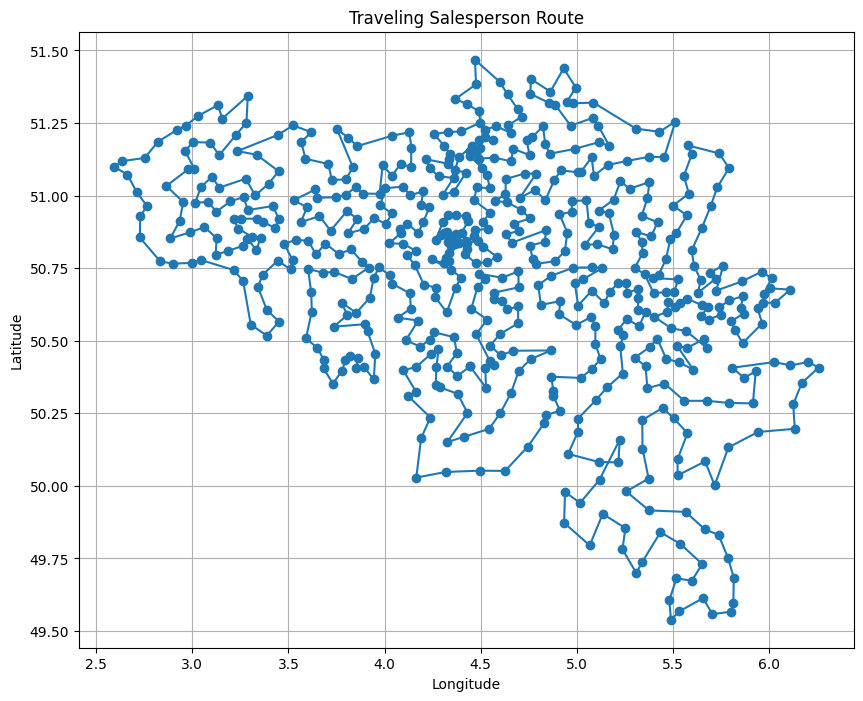

In [176]:
plotRoute(tsp_route)

In [184]:
route_with_distances, total_distance = calculate_route_with_distances(tsp_route, coords, getDistance)

#print_route(route_with_distances)
print_total_distance(total_distance)

Total distance: 4195.52 km


In [186]:
route_with_distances_df = pd.DataFrame(route_with_distances)
print(route_with_distances_df.head())

             from                to  distance
0       CHARLEROI         GERPINNES  11.74 km
1       GERPINNES          CHATELET   8.46 km
2        CHATELET    AISEAU-PRESLES   4.12 km
3  AISEAU-PRESLES        FARCIENNES   4.05 km
4      FARCIENNES  LES BONS VILLERS  11.26 km


In [189]:
route_with_distances_df['neighbors'] = route_with_distances_df.apply(checkNeighbor, axis=1)

In [206]:
neighbors_false_df2 = route_with_distances_df[route_with_distances_df['neighbors'] == False]
print(neighbors_false_df2.shape[0])

57


### Again 57 routes are not included in the neighbors

meaning the distance is inaccurate

In [207]:
new_routes_with_distances_df2 = neighbors_false_df2.copy()
new_routes_with_distances_df2 = new_routes_with_distances_df2.drop(columns=['distance','neighbors'])
new_routes_with_distances_df2 = new_routes_with_distances_df2.rename(columns={'from': 'start', 'to': 'end'})

print(new_routes_with_distances_df2.head())

         start               end
4   FARCIENNES  LES BONS VILLERS
10   TERHULPEN             WAVER
70    GINGELOM            LIJSEM
88     MARCHIN         HAVELANGE
92      CELLES            HOUYET


In [208]:
def getCoords(df):
    features = municipalities_fc['features']
    coords_dict = {}

    for feature in features:
        admunadu_name = feature['properties']['ADMUNADU']
        if 'geometry' in feature and 'coordinates' in feature['geometry']:
            # Assuming points, for polygons or lines, you might need to handle it differently
            coords = feature['geometry']['coordinates']
            coords_dict[admunadu_name] = coords

    # coords_dict now contains ADMUNADU names as keys and coordinates as values
    coords_df = pd.DataFrame(list(coords_dict.items()), columns=['ADMUNADU', 'Coordinates'])
    
    # Merge to get start coordinates
    new_df = df.merge(coords_df, left_on='start', right_on='ADMUNADU', how='left')
    new_df.rename(columns={'Coordinates': 'coords_start'}, inplace=True)
    new_df.drop(columns=['ADMUNADU'], inplace=True)  # Drop the duplicate column after renaming

    # Merge to get end coordinates
    new_df = new_df.merge(coords_df, left_on='end', right_on='ADMUNADU', how='left')
    new_df.rename(columns={'Coordinates': 'coords_end'}, inplace=True)
    new_df.drop(columns=['ADMUNADU'], inplace=True)  # Drop the duplicate column after renaming
    
    return new_df

new_routes_with_distances_df2 = getCoords(new_routes_with_distances_df2)

In [209]:
new_routes_with_distances_df2.head()

,start,end,coords_start,coords_end
0,FARCIENNES,LES BONS VILLERS,"[4.5465179, 50.4318404]","[4.4763492, 50.5226424]"
1,TERHULPEN,WAVER,"[4.4893987, 50.7313729]","[4.610416, 50.7169694]"
2,GINGELOM,LIJSEM,"[5.1332111, 50.7500332]","[5.0318166, 50.711613]"
3,MARCHIN,HAVELANGE,"[5.2263372, 50.4802051]","[5.23958, 50.3870946]"
4,CELLES,HOUYET,"[5.0058339, 50.2312617]","[5.0067044, 50.1868629]"


In [210]:
new_routes_with_distances_df2['Directions'] = None

In [211]:
new_routes_with_distances_df2 = process_dataframe(new_routes_with_distances_df2)
    
none_counts = new_routes_with_distances_df2['Directions'].isna().sum()
print(none_counts)

0


In [212]:
new_routes_with_distances_df2['Distances'] = new_routes_with_distances_df2['Directions'].apply(extract_distance)

In [214]:
print(new_routes_with_distances_df2.shape[0])
new_routes_with_distances_df2.head()

57


,start,end,coords_start,coords_end,Directions,Distances
0,FARCIENNES,LES BONS VILLERS,"[4.5465179, 50.4318404]","[4.4763492, 50.5226424]","[{'bounds': {'northeast': {'lat': 50.523731, '...",13699
1,TERHULPEN,WAVER,"[4.4893987, 50.7313729]","[4.610416, 50.7169694]","[{'bounds': {'northeast': {'lat': 50.7347826, ...",10376
2,GINGELOM,LIJSEM,"[5.1332111, 50.7500332]","[5.0318166, 50.711613]","[{'bounds': {'northeast': {'lat': 50.7500157, ...",9470
3,MARCHIN,HAVELANGE,"[5.2263372, 50.4802051]","[5.23958, 50.3870946]","[{'bounds': {'northeast': {'lat': 50.4800869, ...",11223
4,CELLES,HOUYET,"[5.0058339, 50.2312617]","[5.0067044, 50.1868629]","[{'bounds': {'northeast': {'lat': 50.2316331, ...",9128


In [222]:
new_distances_df.shape[0]

1753

In [255]:
new_distances_df = pd.concat([distances_df, new_routes_with_distances_df, new_routes_with_distances_df2 ], ignore_index=True)
print('initial distances: ' + str(distances_df.shape[0]))
print('new distances: ' + str(new_routes_with_distances_df.shape[0]))
print('new distances2: ' + str(new_routes_with_distances_df2.shape[0]))
print('total distances: ' + str(new_distances_df.shape[0]))

initial distances: 1623
new distances: 73
new distances2: 57
total distances: 1753


In [259]:
new_distances_df.head()

,start,end,coords_start,coords_end,Directions,Distances
0,AARTSELAAR,ANTWERPEN,"[4.3870241, 51.133297]","[4.3997081, 51.2211097]",[{'bounds': {'northeast': {'lat': 51.221048300...,10524
1,AARTSELAAR,EDEGEM,"[4.3870241, 51.133297]","[4.4458312, 51.1548066]","[{'bounds': {'northeast': {'lat': 51.1567202, ...",6554
2,AARTSELAAR,HEMIKSEM,"[4.3870241, 51.133297]","[4.3409826, 51.1430192]","[{'bounds': {'northeast': {'lat': 51.1434357, ...",4148
3,AARTSELAAR,KONTICH,"[4.3870241, 51.133297]","[4.4454784, 51.1353297]","[{'bounds': {'northeast': {'lat': 51.1436259, ...",5028
4,AARTSELAAR,NIEL,"[4.3870241, 51.133297]","[4.3303396, 51.1098649]","[{'bounds': {'northeast': {'lat': 51.1334287, ...",6084


### recalculate again with 57 new distances

In [260]:
G = nx.Graph()
nodes = addNodes(municipalities_fc, 'ADMUNADU')
distance_dict = get_distance_dict(new_distances_df)
addEdges(nodes)                  

In [261]:
tsp_route = nx.approximation.christofides(G, weight='weight')

In [262]:
startWithSpecificNode(G, 'HOVE', tsp_route)
tsp_route = clean_route(tsp_route)

TSP Route using Christofides algorithm starting from HOVE : ['HOVE', 'LINT', 'BOECHOUT', 'BORSBEEK', 'WOMMELGEM', 'RANST', 'WIJNEGEM', 'SCHILDE', 'HAL', 'ZANDHOVEN', 'ZOERSEL', 'MALLE', 'BRECHT', 'WUUSTWEZEL', 'ESSEN', 'KALMTHOUT', 'KAPELLEN', 'STABROEK', 'BRASSCHAAT', 'SCHOTEN', 'ANTWERPEN', 'ZWIJNDRECHT', 'BEVEREN', 'KRUIBEKE', 'SCHELLE', 'NIEL', 'BOOM', 'WILLEBROEK', 'PUURS-SINT-AMANDS', 'BORNEM', 'HAMME', 'WAASMUNSTER', 'ZELE', 'LOKEREN', 'BERLARE', 'LEDE', 'AALST', 'AFFLIGEM', 'TERNAT', 'ASSE', 'MERCHTEM', 'OPWIJK', 'LEBBEKE', 'DENDERMONDE', 'BUGGENHOUT', 'LONDERZEEL', 'KAPELLE-OP-DEN-BOS', 'RUMST', 'MECHELEN', 'ZEMST', 'MACHELEN', 'VILVOORDE', 'GRIMBERGEN', 'MEISE', 'WEMMEL', 'GANSHOREN', 'DILBEEK', 'SINT-AGATHA-BERCHEM', 'JETTE', 'KOEKELBERG', 'SINT-JANS-MOLENBEEK', 'BRUSSEL', 'ANDERLECHT', 'SINT-JOOST-TEN-NODE', 'ETTERBEEK', 'SCHAARBEEK', 'EVERE', 'SINT-LAMBRECHTS-WOLUWE', 'SINT-PIETERS-WOLUWE', 'OUDERGHEM', 'WATERMAAL-BOSVOORDE', 'HOEILAART', 'HULDENBERG', 'OVERIJSE', 'TERHULP

In [263]:
tsp_route = two_opt(G, tsp_route)

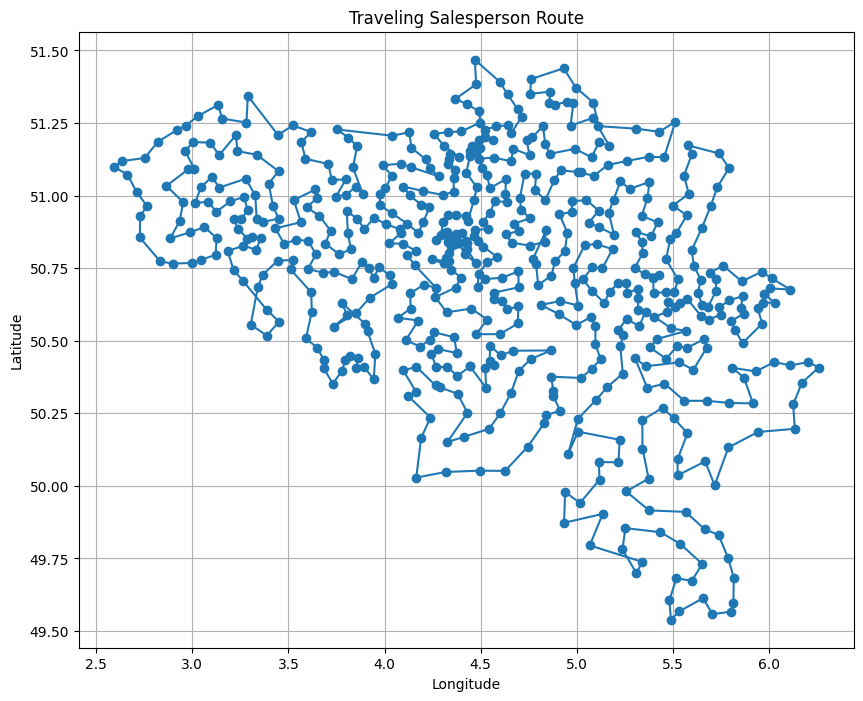

In [264]:
plotRoute(tsp_route)

In [265]:
route_with_distances, total_distance = calculate_route_with_distances(tsp_route, getDistance)

#print_route(route_with_distances)
print_total_distance(total_distance)

Total distance: 4226.07 km


In [266]:
def checkNeighbor(row):
    f = row['from']
    t = row['to']
    return (f, t) in distance_dict or (t, f) in distance_dict

In [292]:
route_with_distances_df = pd.DataFrame(route_with_distances)
route_with_distances_df['neighbors'] = route_with_distances_df.apply(checkNeighbor, axis=1)

neighbors_false_df3 = route_with_distances_df[route_with_distances_df['neighbors'] == False]
print("Number of false neighbors: " + str(neighbors_false_df3.shape[0]))

Number of false neighbors: 16


### get 32 new distances

In [271]:
def getNewDistances(df):
    new_df = df.copy()
    new_df = new_df.drop(columns=['distance','neighbors'])
    new_df = new_df.rename(columns={'from': 'start', 'to': 'end'})

    new_df = getCoords(new_df)

    new_df['Directions'] = None

    new_df = process_dataframe(new_df)
        
    none_counts = new_df['Directions'].isna().sum()
    print("directions to do: " + str(none_counts))

    new_df['Distances'] = new_df['Directions'].apply(extract_distance)
    
    print("number of new directions: " + str(new_df.shape[0]))
    
    return new_df

In [272]:
new_routes_with_distances_df3 = getNewDistances(neighbors_false_df3)

directions to do: 0
number of new directions: 32


In [273]:
new_distances_df = pd.concat([distances_df, new_routes_with_distances_df, new_routes_with_distances_df2, new_routes_with_distances_df3], ignore_index=True)
print('initial distances: ' + str(distances_df.shape[0]))
print('new distances: ' + str(new_routes_with_distances_df.shape[0]))
print('new distances2: ' + str(new_routes_with_distances_df2.shape[0]))
print('new distances2: ' + str(new_routes_with_distances_df3.shape[0]))
print('total distances: ' + str(new_distances_df.shape[0]))

initial distances: 1623
new distances: 73
new distances2: 57
new distances2: 32
total distances: 1785


### recalculate again with 32 new distances

In [281]:
G = nx.Graph()
nodes = addNodes(municipalities_fc, 'ADMUNADU')
distance_dict = get_distance_dict(new_distances_df)
addEdges(nodes)     
    

In [285]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the graph connected?", "Yes" if nx.is_connected(G) else "No")

Number of nodes: 581
Number of edges: 168490
Is the graph connected? Yes


In [286]:
tsp_route = nx.approximation.christofides(G, weight='weight')

startWithSpecificNode(G, 'HOVE', tsp_route)
tsp_route = clean_route(tsp_route)

tsp_route = two_opt(G, tsp_route)

TSP Route using Christofides algorithm starting from HOVE : ['HOVE', 'LINT', 'BOECHOUT', 'BORSBEEK', 'WOMMELGEM', 'RANST', 'WIJNEGEM', 'SCHILDE', 'HAL', 'ZANDHOVEN', 'ZOERSEL', 'MALLE', 'BRECHT', 'WUUSTWEZEL', 'ESSEN', 'KALMTHOUT', 'KAPELLEN', 'STABROEK', 'BRASSCHAAT', 'SCHOTEN', 'ANTWERPEN', 'ZWIJNDRECHT', 'BEVEREN', 'KRUIBEKE', 'SCHELLE', 'NIEL', 'BOOM', 'WILLEBROEK', 'PUURS-SINT-AMANDS', 'BORNEM', 'SINT-NIKLAAS', 'SINT-GILLIS-WAAS', 'STEKENE', 'LOKEREN', 'LEDE', 'AALST', 'AFFLIGEM', 'TERNAT', 'ASSE', 'MERCHTEM', 'OPWIJK', 'LEBBEKE', 'DENDERMONDE', 'BUGGENHOUT', 'LONDERZEEL', 'KAPELLE-OP-DEN-BOS', 'RUMST', 'MECHELEN', 'ZEMST', 'MACHELEN', 'VILVOORDE', 'GRIMBERGEN', 'MEISE', 'WEMMEL', 'GANSHOREN', 'DILBEEK', 'SINT-AGATHA-BERCHEM', 'JETTE', 'KOEKELBERG', 'SINT-JANS-MOLENBEEK', 'BRUSSEL', 'ANDERLECHT', 'SINT-JOOST-TEN-NODE', 'ETTERBEEK', 'SCHAARBEEK', 'EVERE', 'SINT-LAMBRECHTS-WOLUWE', 'SINT-PIETERS-WOLUWE', 'OUDERGHEM', 'WATERMAAL-BOSVOORDE', 'HOEILAART', 'HULDENBERG', 'OVERIJSE', 'TER

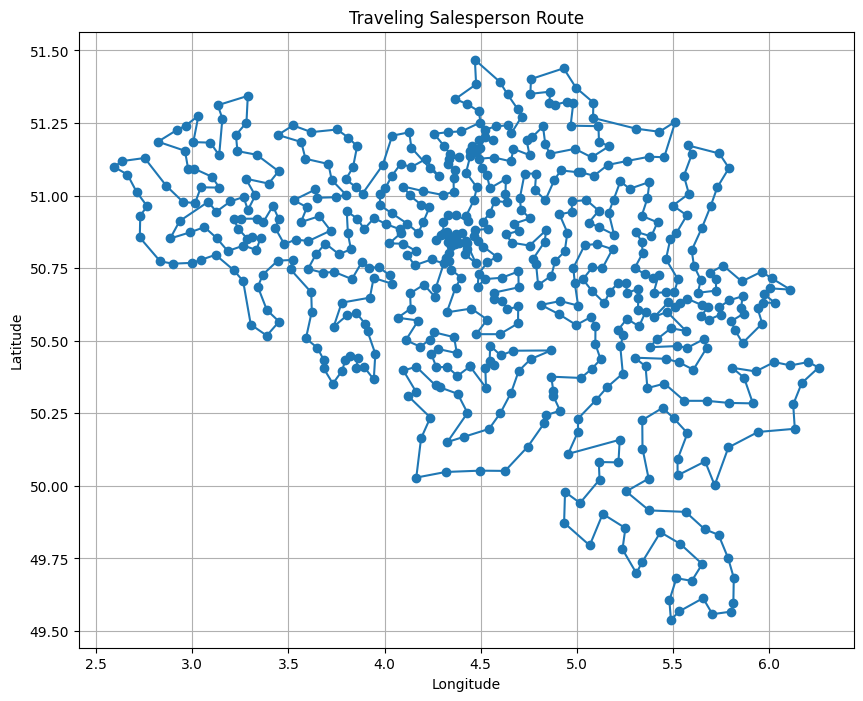

In [287]:
plotRoute(tsp_route)

In [288]:
route_with_distances, total_distance = calculate_route_with_distances(tsp_route, getDistance)

print_total_distance(total_distance)
#print_route(route_with_distances)

Total distance: 4241.90 km


In [290]:
route_with_distances_df = pd.DataFrame(route_with_distances)
route_with_distances_df['neighbors'] = route_with_distances_df.apply(checkNeighbor, axis=1)

neighbors_false_df4 = route_with_distances_df[route_with_distances_df['neighbors'] == False]
print("Number of false neighbors: " + str(neighbors_false_df4.shape[0]))

Number of false neighbors: 16


### get 16 new distances

In [294]:
new_routes_with_distances_df4 = getNewDistances(neighbors_false_df4)

directions to do: 0
number of new directions: 16


In [ ]:
new_distances_df = pd.concat([distances_df, new_routes_with_distances_df, new_routes_with_distances_df2, new_routes_with_distances_df3,new_routes_with_distances_df4], ignore_index=True)
print('initial distances: ' + str(distances_df.shape[0]))
print('new distances: ' + str(new_routes_with_distances_df.shape[0]))
print('new distances2: ' + str(new_routes_with_distances_df2.shape[0]))
print('new distances3: ' + str(new_routes_with_distances_df3.shape[0]))
print('new distances4: ' + str(new_routes_with_distances_df4.shape[0]))
print('total distances: ' + str(new_distances_df.shape[0]))

In [295]:
new_distances_df = pd.concat([new_distances_df, new_routes_with_distances_df4], ignore_index=True)
print('total distances: ' + str(new_distances_df.shape[0]))

total distances: 1801


### recalculate again with 16 new distances

In [296]:
G = nx.Graph()
nodes = addNodes(municipalities_fc, 'ADMUNADU')
distance_dict = get_distance_dict(new_distances_df)
addEdges(nodes)   

In [297]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the graph connected?", "Yes" if nx.is_connected(G) else "No")

Number of nodes: 581
Number of edges: 168490
Is the graph connected? Yes


In [298]:
tsp_route = nx.approximation.christofides(G, weight='weight')

startWithSpecificNode(G, 'HOVE', tsp_route)
tsp_route = clean_route(tsp_route)

tsp_route = two_opt(G, tsp_route)

TSP Route using Christofides algorithm starting from HOVE : ['HOVE', 'BOECHOUT', 'BORSBEEK', 'WOMMELGEM', 'RANST', 'WIJNEGEM', 'SCHILDE', 'HAL', 'ZANDHOVEN', 'ZOERSEL', 'MALLE', 'BRECHT', 'WUUSTWEZEL', 'ESSEN', 'KALMTHOUT', 'KAPELLEN', 'STABROEK', 'BRASSCHAAT', 'SCHOTEN', 'ANTWERPEN', 'ZWIJNDRECHT', 'BEVEREN', 'KRUIBEKE', 'AARTSELAAR', 'KONTICH', 'EDEGEM', 'MORTSEL', 'LIER', 'BERLAAR', 'NIJLEN', 'HERENTHOUT', 'GROBBENDONK', 'VORSELAAR', 'LILLE', 'HERENTALS', 'OLEN', 'WESTERLO', 'HERSELT', 'LAAKDAL', 'VORST', 'MEERHOUT', 'GEEL', 'KASTERLEE', 'RETIE', 'ARENDONK', 'OUD-TURNHOUT', 'TURNHOUT', 'RAVELS', 'BAARLE-HERTOG', 'HOOGSTRATEN', 'RIJKEVORSEL', 'MERKSPLAS', 'BEERSE', 'VOSSELAAR', 'DESSEL', 'MOL', 'BALEN', 'TESSENDERLO', 'HAM', 'LEOPOLDSBURG', 'HECHTEL-EKSEL', 'PELT', 'HAMONT-ACHEL', 'LOMMEL', 'PEER', 'HOUTHALEN-HELCHTEREN', 'ZONHOVEN', 'HASSELT', 'DIEPENBEEK', 'KORTESSEM', 'WELLEN', 'ALKEN', 'BORGLOON', 'HEERS', 'OERLE', 'CRISNEE', 'JUPRELLE', 'ANS', 'SAINT-NICOLAS', 'AWANS', 'FEXHE-LE

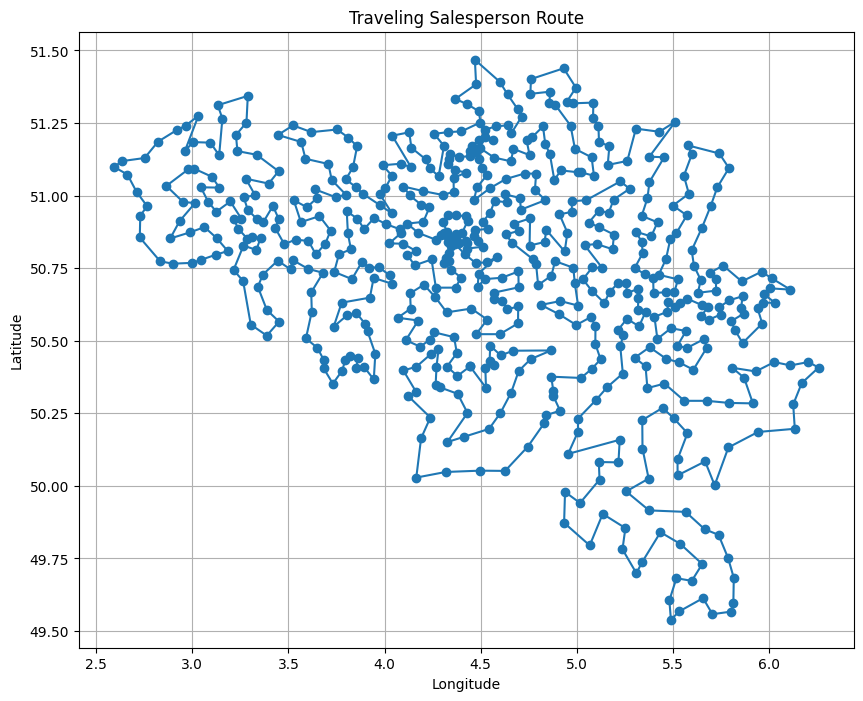

In [299]:
plotRoute(tsp_route)

In [300]:
route_with_distances, total_distance = calculate_route_with_distances(tsp_route, getDistance)

print_total_distance(total_distance)

Total distance: 4225.96 km


In [303]:
route_with_distances_df = pd.DataFrame(route_with_distances)
route_with_distances_df['neighbors'] = route_with_distances_df.apply(checkNeighbor, axis=1)

neighbors_false_df5 = route_with_distances_df[route_with_distances_df['neighbors'] == False]
print("Number of false neighbors: " + str(neighbors_false_df5.shape[0]))

Number of false neighbors: 15


### get 15 new distances

In [304]:
new_routes_with_distances_df5 = getNewDistances(neighbors_false_df5)

directions to do: 0
number of new directions: 15


In [305]:
new_distances_df = pd.concat([new_distances_df, new_routes_with_distances_df5], ignore_index=True)
print('total distances: ' + str(new_distances_df.shape[0]))

total distances: 1816


### recalculate again with 15 new distances

In [307]:
def buildGraph(G):
    nodes = addNodes(municipalities_fc, 'ADMUNADU')
    addEdges(nodes)  

In [308]:
G = nx.Graph()

buildGraph(G)
distance_dict = get_distance_dict(new_distances_df)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the graph connected?", "Yes" if nx.is_connected(G) else "No")

Number of nodes: 581
Number of edges: 168490
Is the graph connected? Yes


In [309]:
tsp_route = nx.approximation.christofides(G, weight='weight')

startWithSpecificNode(G, 'HOVE', tsp_route)
tsp_route = clean_route(tsp_route)

tsp_route = two_opt(G, tsp_route)

TSP Route using Christofides algorithm starting from HOVE : ['HOVE', 'BOECHOUT', 'BORSBEEK', 'WOMMELGEM', 'RANST', 'WIJNEGEM', 'SCHILDE', 'HAL', 'ZANDHOVEN', 'ZOERSEL', 'MALLE', 'BRECHT', 'WUUSTWEZEL', 'ESSEN', 'KALMTHOUT', 'KAPELLEN', 'STABROEK', 'BRASSCHAAT', 'SCHOTEN', 'ANTWERPEN', 'ZWIJNDRECHT', 'BEVEREN', 'KRUIBEKE', 'AARTSELAAR', 'KONTICH', 'EDEGEM', 'MORTSEL', 'LIER', 'BERLAAR', 'NIJLEN', 'HERENTHOUT', 'GROBBENDONK', 'VORSELAAR', 'LILLE', 'HERENTALS', 'OLEN', 'WESTERLO', 'HERSELT', 'LAAKDAL', 'VORST', 'MEERHOUT', 'GEEL', 'KASTERLEE', 'RETIE', 'ARENDONK', 'OUD-TURNHOUT', 'TURNHOUT', 'RAVELS', 'BAARLE-HERTOG', 'HOOGSTRATEN', 'RIJKEVORSEL', 'MERKSPLAS', 'BEERSE', 'VOSSELAAR', 'DESSEL', 'MOL', 'BALEN', 'TESSENDERLO', 'HAM', 'LEOPOLDSBURG', 'HECHTEL-EKSEL', 'PELT', 'HAMONT-ACHEL', 'LOMMEL', 'PEER', 'HOUTHALEN-HELCHTEREN', 'ZONHOVEN', 'HASSELT', 'DIEPENBEEK', 'KORTESSEM', 'WELLEN', 'ALKEN', 'BORGLOON', 'HEERS', 'OERLE', 'CRISNEE', 'JUPRELLE', 'ANS', 'SAINT-NICOLAS', 'AWANS', 'FEXHE-LE

In [310]:
route_with_distances, total_distance = calculate_route_with_distances(tsp_route, getDistance)
print_total_distance(total_distance)

route_with_distances_df = pd.DataFrame(route_with_distances)
route_with_distances_df['neighbors'] = route_with_distances_df.apply(checkNeighbor, axis=1)

neighbors_false_df5 = route_with_distances_df[route_with_distances_df['neighbors'] == False]
print("Number of false neighbors: " + str(neighbors_false_df5.shape[0]))

Total distance: 4255.77 km
Number of false neighbors: 0


In [312]:
print(new_routes_with_distances_df.shape[0])

582


In [313]:
new_distances_df

,start,end,coords_start,coords_end,Directions,Distances
0,AARTSELAAR,ANTWERPEN,"[4.3870241, 51.133297]","[4.3997081, 51.2211097]",[{'bounds': {'northeast': {'lat': 51.221048300...,10524
1,AARTSELAAR,EDEGEM,"[4.3870241, 51.133297]","[4.4458312, 51.1548066]","[{'bounds': {'northeast': {'lat': 51.1567202, ...",6554
2,AARTSELAAR,HEMIKSEM,"[4.3870241, 51.133297]","[4.3409826, 51.1430192]","[{'bounds': {'northeast': {'lat': 51.1434357, ...",4148
3,AARTSELAAR,KONTICH,"[4.3870241, 51.133297]","[4.4454784, 51.1353297]","[{'bounds': {'northeast': {'lat': 51.1436259, ...",5028
4,AARTSELAAR,NIEL,"[4.3870241, 51.133297]","[4.3303396, 51.1098649]","[{'bounds': {'northeast': {'lat': 51.1334287, ...",6084
...,...,...,...,...,...,...
1811,WICHELEN,AALST,"[3.9742524, 51.0060797]","[4.0392147, 50.9383226]","[{'bounds': {'northeast': {'lat': 51.0065067, ...",10288
1812,GISTEL,DE HAAN,"[2.961541, 51.1542785]","[3.03169, 51.275083]","[{'bounds': {'northeast': {'lat': 51.2752388, ...",18217
1813,ARDOOIE,INGELMUNSTER,"[3.1974259, 50.9797876]","[3.2549979, 50.9202812]","[{'bounds': {'northeast': {'lat': 50.9797717, ...",8992
1814,SINT-PIETERS-LEEUW,KASTEELBRAKEL,"[4.2443604, 50.7800261]","[4.2669864, 50.6827864]","[{'bounds': {'northeast': {'lat': 50.7798549, ...",12132


In [315]:
new_distances_df.to_csv('routes_with_distances.csv', index=False)

## check if dataset is OK

In [316]:
def loadFeatureCollection(filename):
    # Path to the GeoJSON file
    filename = 'municipalitiesWithADMUNADU.geojson'

    # Read the GeoJSON file
    with open(filename, 'r') as file:
        fc = json.load(file)

    # Print the number of features
    num_features = len(fc['features'])
    print("Number of features:", num_features)

    print(fc['features'][0])
    
    return fc
    
municipalities_fc = loadFeatureCollection('municipalitiesWithADMUNADU.geojson')

Number of features: 581
{'type': 'Feature', 'properties': {'name': 'Charleroi', 'place': 'city', 'ADMUNADU': 'CHARLEROI'}, 'geometry': {'type': 'Point', 'coordinates': [4.444528, 50.4116233]}}


In [326]:
csv_file_path = 'routes_with_distances.csv' 
distances_df = pd.read_csv(csv_file_path)
print(distances_df.shape[0])
print(distances_df.loc[0])

1816
start                                                  AARTSELAAR
end                                                     ANTWERPEN
coords_start                               [4.3870241, 51.133297]
coords_end                                [4.3997081, 51.2211097]
Directions      [{'bounds': {'northeast': {'lat': 51.221048300...
Distances                                                   10524
Name: 0, dtype: object


In [319]:
G = nx.Graph()
nodes = addNodes(municipalities_fc, 'ADMUNADU')
distance_dict = get_distance_dict(distances_df)
addEdges(nodes)    

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the graph connected?", "Yes" if nx.is_connected(G) else "No")

Number of nodes: 581
Number of edges: 168490
Is the graph connected? Yes


In [320]:
tsp_route = nx.approximation.christofides(G, weight='weight')

startWithSpecificNode(G, 'HOVE', tsp_route)
tsp_route = clean_route(tsp_route)

tsp_route = two_opt(G, tsp_route)

TSP Route using Christofides algorithm starting from HOVE : ['HOVE', 'LINT', 'BOECHOUT', 'BORSBEEK', 'WOMMELGEM', 'RANST', 'WIJNEGEM', 'SCHILDE', 'HAL', 'ZANDHOVEN', 'ZOERSEL', 'MALLE', 'BRECHT', 'WUUSTWEZEL', 'ESSEN', 'KALMTHOUT', 'KAPELLEN', 'STABROEK', 'BRASSCHAAT', 'SCHOTEN', 'ANTWERPEN', 'ZWIJNDRECHT', 'BEVEREN', 'KRUIBEKE', 'SCHELLE', 'NIEL', 'BOOM', 'WILLEBROEK', 'PUURS-SINT-AMANDS', 'BORNEM', 'SINT-NIKLAAS', 'SINT-GILLIS-WAAS', 'STEKENE', 'LOKEREN', 'LEDE', 'AALST', 'AFFLIGEM', 'TERNAT', 'ASSE', 'MERCHTEM', 'OPWIJK', 'LEBBEKE', 'DENDERMONDE', 'BUGGENHOUT', 'LONDERZEEL', 'KAPELLE-OP-DEN-BOS', 'RUMST', 'MECHELEN', 'ZEMST', 'MACHELEN', 'VILVOORDE', 'GRIMBERGEN', 'MEISE', 'WEMMEL', 'JETTE', 'DILBEEK', 'SINT-AGATHA-BERCHEM', 'GANSHOREN', 'KOEKELBERG', 'SINT-JANS-MOLENBEEK', 'BRUSSEL', 'ANDERLECHT', 'ELSENE', 'SINT-JOOST-TEN-NODE', 'SCHAARBEEK', 'EVERE', 'SINT-LAMBRECHTS-WOLUWE', 'SINT-PIETERS-WOLUWE', 'OUDERGHEM', 'WATERMAAL-BOSVOORDE', 'HOEILAART', 'HULDENBERG', 'OVERIJSE', 'TERHUL

In [321]:
route_with_distances, total_distance = calculate_route_with_distances(tsp_route, getDistance)

print_total_distance(total_distance)

Total distance: 4243.26 km


In [322]:
route_with_distances_df = pd.DataFrame(route_with_distances)
route_with_distances_df['neighbors'] = route_with_distances_df.apply(checkNeighbor, axis=1)

neighbors_false_df= route_with_distances_df[route_with_distances_df['neighbors'] == False]
print("Number of false neighbors: " + str(neighbors_false_df.shape[0]))

Number of false neighbors: 5


TODO: get all the possible routes with distances

The way we do it now is just getting the routes that are used in the calculated path 
But different paths use different routes

We need a better way to get the necesarry connections

We should inspect the data 

We could just calculate all routes less than 10km 
Let's check the dataset of used routes which is the longest 

In [329]:
distances_df

,start,end,coords_start,coords_end,Directions,Distances
0,AARTSELAAR,ANTWERPEN,"[4.3870241, 51.133297]","[4.3997081, 51.2211097]",[{'bounds': {'northeast': {'lat': 51.221048300...,10524
1,AARTSELAAR,EDEGEM,"[4.3870241, 51.133297]","[4.4458312, 51.1548066]","[{'bounds': {'northeast': {'lat': 51.1567202, ...",6554
2,AARTSELAAR,HEMIKSEM,"[4.3870241, 51.133297]","[4.3409826, 51.1430192]","[{'bounds': {'northeast': {'lat': 51.1434357, ...",4148
3,AARTSELAAR,KONTICH,"[4.3870241, 51.133297]","[4.4454784, 51.1353297]","[{'bounds': {'northeast': {'lat': 51.1436259, ...",5028
4,AARTSELAAR,NIEL,"[4.3870241, 51.133297]","[4.3303396, 51.1098649]","[{'bounds': {'northeast': {'lat': 51.1334287, ...",6084
...,...,...,...,...,...,...
1811,WICHELEN,AALST,"[3.9742524, 51.0060797]","[4.0392147, 50.9383226]","[{'bounds': {'northeast': {'lat': 51.0065067, ...",10288
1812,GISTEL,DE HAAN,"[2.961541, 51.1542785]","[3.03169, 51.275083]","[{'bounds': {'northeast': {'lat': 51.2752388, ...",18217
1813,ARDOOIE,INGELMUNSTER,"[3.1974259, 50.9797876]","[3.2549979, 50.9202812]","[{'bounds': {'northeast': {'lat': 50.9797717, ...",8992
1814,SINT-PIETERS-LEEUW,KASTEELBRAKEL,"[4.2443604, 50.7800261]","[4.2669864, 50.6827864]","[{'bounds': {'northeast': {'lat': 50.7798549, ...",12132


In [330]:
# Calculate statistics
min_distance = distances_df['Distances'].min()
max_distance = distances_df['Distances'].max()
mean_distance = distances_df['Distances'].mean()
median_distance = distances_df['Distances'].median()
std_distance = distances_df['Distances'].std()
percentile_25 = distances_df['Distances'].quantile(0.25)
percentile_75 = distances_df['Distances'].quantile(0.75)
summary_statistics = distances_df['Distances'].describe()

# Print statistics
print(f"Minimum Distance: {min_distance} meters")
print(f"Maximum Distance: {max_distance} meters")
print(f"Mean Distance: {mean_distance:.2f} meters")
print(f"Median Distance: {median_distance:.2f} meters")
print(f"Standard Deviation: {std_distance:.2f} meters")
print(f"25th Percentile: {percentile_25} meters")
print(f"75th Percentile: {percentile_75} meters")
print("\nSummary Statistics:")
print(summary_statistics)

Minimum Distance: 0 meters
Maximum Distance: 148453 meters
Mean Distance: 10581.76 meters
Median Distance: 9192.50 meters
Standard Deviation: 9945.27 meters
25th Percentile: 6802.5 meters
75th Percentile: 12132.25 meters

Summary Statistics:
count      1816.000000
mean      10581.760463
std        9945.270739
min           0.000000
25%        6802.500000
50%        9192.500000
75%       12132.250000
max      148453.000000
Name: Distances, dtype: float64


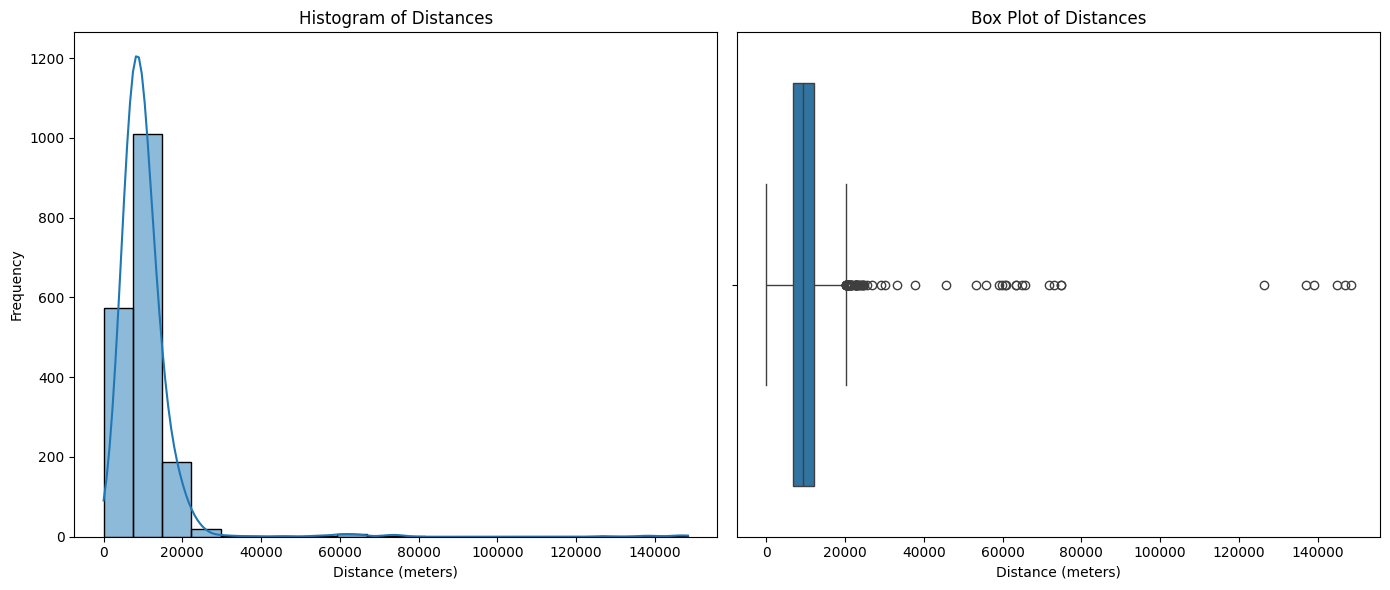

In [332]:
import seaborn as sns

# Plotting the data
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(distances_df['Distances'], kde=True, bins=20)
plt.title('Histogram of Distances')
plt.xlabel('Distance (meters)')
plt.ylabel('Frequency')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(x=distances_df['Distances'])
plt.title('Box Plot of Distances')
plt.xlabel('Distance (meters)')

plt.tight_layout()
plt.show()

cleanup data

In [335]:
zeroes = distances_df[distances_df['Distances'] == 0]
zeroes

,start,end,coords_start,coords_end,Directions,Distances
1752,CHARLEROI,CHARLEROI,"[4.444528, 50.4116233]","[4.444528, 50.4116233]","[{'bounds': {'northeast': {'lat': 50.4115753, ...",0


In [425]:
hundos = distances_df[distances_df['Distances'] > 100000].copy()
hundos

,start,end,coords_start,coords_end,Directions,Distances
648,AVELGEM,CELLES,"[3.4444479, 50.7758362]","[5.0058339, 50.2312617]","[{'bounds': {'northeast': {'lat': 50.7756494, ...",144909
683,SPIERE-HELKIJN,CELLES,"[3.3667739, 50.7279919]","[5.0058339, 50.2312617]",[{'bounds': {'northeast': {'lat': 50.731874700...,148453
927,FRASNES-LEZ-ANVAING,CELLES,"[3.6184362, 50.6667214]","[5.0058339, 50.2312617]","[{'bounds': {'northeast': {'lat': 50.6667214, ...",126363
1060,CELLES,PECQ,"[5.0058339, 50.2312617]","[3.3407492, 50.685616]",[{'bounds': {'northeast': {'lat': 50.685496699...,147019
1061,CELLES,DOORNIK,"[5.0058339, 50.2312617]","[3.3878179, 50.6056458]","[{'bounds': {'northeast': {'lat': 50.6077595, ...",136969
1062,CELLES,MONT-DE-L'ENCLUS,"[5.0058339, 50.2312617]","[3.5110542, 50.7456511]","[{'bounds': {'northeast': {'lat': 50.7505596, ...",139114


There seems to be something wrong with celles, the distances shouldn't be that far

In [431]:
import ast

def convert_to_list(cell):
    try:
        return ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return cell

hundos['coords_start'] = hundos['coords_start'].apply(convert_to_list)
hundos['coords_end'] = hundos['coords_end'].apply(convert_to_list)
hundos['Directions'] = hundos['Directions'].apply(convert_to_list)

In [429]:
# def get_directions(row):
#     origin = (row['coords_start'][1], row['coords_start'][0])
#     destination = (row['coords_end'][1], row['coords_end'][0])
    
#     print(origin, destination)
#     directions = gmaps.directions(origin, destination, mode="walking", units="metric")
#     return directions


# new_dirs = get_directions(hundos.loc[648])
# print(new_dirs)

In [437]:
weird_directions = hundos.loc[648,'Directions']

In [439]:
import folium
# Extract the polyline of the first route
polyline = weird_directions[0]['overview_polyline']['points']

# Decode polyline (Folium can't use the encoded polyline directly)
decoded_path = googlemaps.convert.decode_polyline(polyline)

# Convert path from dictionaries to tuples of (latitude, longitude)
path = [(point['lat'], point['lng']) for point in decoded_path]

# Create a map object centered and zoomed on the first coordinate of the path
map = folium.Map(location=path[0], zoom_start=11)

# Add a polyline to the map with the decoded path coordinates
folium.PolyLine(path).add_to(map)

# Optionally, add markers for the start and end of the route
# Ensuring popup strings are only strings
folium.Marker(location=path[0], popup=f'Start', icon=folium.Icon(color='green')).add_to(map)
folium.Marker(location=path[-1], popup=f'End', icon=folium.Icon(color='red')).add_to(map)

# Display the map
map